In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance

In [25]:
# import drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Monthly data, with seasonal terciles for each month

For example, month 3 will have MAM's tercile, and so will month 4 and 5.

In [71]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data/eea_mam_ml_data_monthly_seasonal_tercile.csv", index_col=0)

# drop precip
df = df.drop(columns=['precip'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019, 2020]

test_years = [2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [72]:
# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [73]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       1.00      0.50      0.67         6
          bn       0.67      1.00      0.80         6
           n       0.00      0.00      0.00         0

    accuracy                           0.75        12
   macro avg       0.56      0.50      0.49        12
weighted avg       0.83      0.75      0.73        12



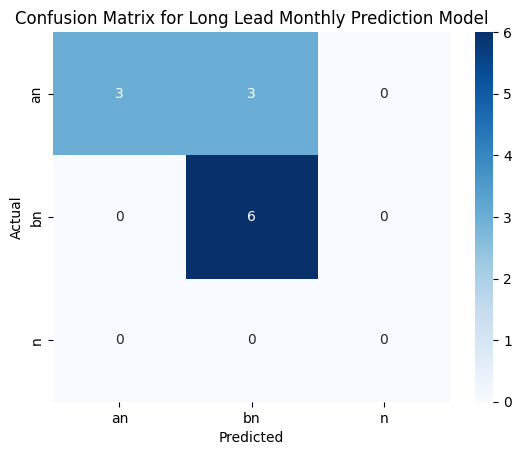

In [74]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Long Lead Monthly Prediction Model')
plt.show()

We see that the model never predicted N, and the test data also never had an N tercile for the years 2021-2024 for the MAM season. The model misclassified AN as BN 3 times, but correctly classified all BN years. Thus, the model may be biased towards BN observations, and this may be due to our predictors being biased towards BN.


<Figure size 1000x600 with 0 Axes>

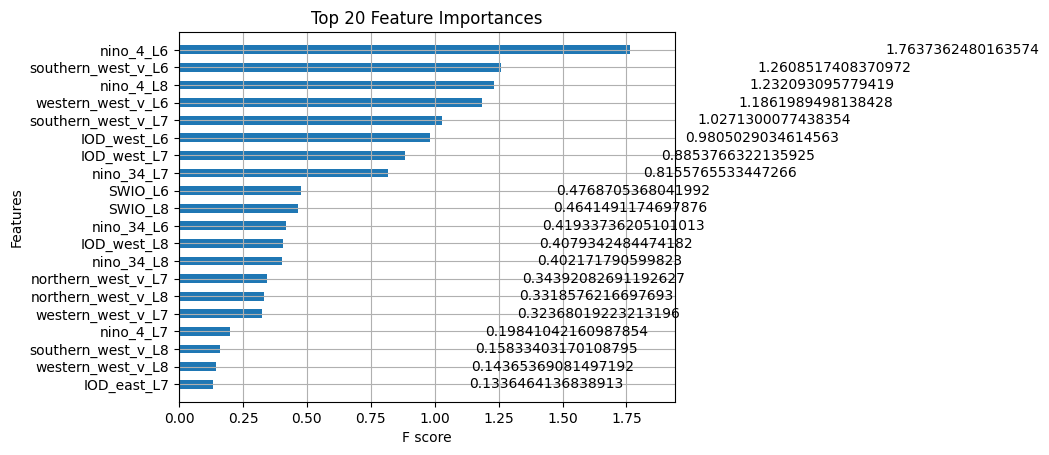

In [75]:
# Feature importance plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type='gain', height=0.5)
plt.title("Top 20 Feature Importances")
plt.show()

In [76]:
# Reset index to ensure alignment
test_info = test_df[['year', 'month']].reset_index(drop=True)
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

# Concatenate year, month, and predicted probabilities
results_df = pd.concat([test_info, proba_df], axis=1)

# Optional: add predicted and true class labels
results_df['true_label'] = le.inverse_transform(y_test_enc)
results_df['predicted_label'] = le.inverse_transform(y_pred)

# Print full DataFrame
print("=== EEA MAM (Monthly, Seasonal Terciles) Predictions with Probabilities ===")
print(results_df.to_string(index=False))

=== EEA MAM (Monthly, Seasonal Terciles) Predictions with Probabilities ===
 year  month  proba_an  proba_bn  proba_n true_label predicted_label
 2021      3  0.080089  0.870102 0.049810         bn              bn
 2021      4  0.223452  0.674607 0.101941         bn              bn
 2021      5  0.227821  0.612057 0.160123         bn              bn
 2022      3  0.053329  0.774942 0.171728         bn              bn
 2022      4  0.015712  0.951560 0.032729         bn              bn
 2022      5  0.023455  0.931584 0.044961         bn              bn
 2023      3  0.041858  0.840804 0.117337         an              bn
 2023      4  0.046532  0.826723 0.126746         an              bn
 2023      5  0.031248  0.839975 0.128777         an              bn
 2024      3  0.806453  0.146501 0.047046         an              an
 2024      4  0.826671  0.125103 0.048226         an              an
 2024      5  0.719901  0.111288 0.168811         an              an


Here we can see what probability of tercile category the model predicted for each year and each month in the testing data.

# Seasonal

Seasonal data with seasonal tercile

1993 MAM has 1993 MAM's tercile

In [59]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data/eea_mam_ml_data_seasonal.csv")

# drop precip
df = df.drop(columns=['precip', 'season'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019]

test_years = [2020, 2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [60]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       1.00      0.67      0.80         3
          bn       0.67      1.00      0.80         2
           n       0.00      0.00      0.00         0

    accuracy                           0.80         5
   macro avg       0.56      0.56      0.53         5
weighted avg       0.87      0.80      0.80         5



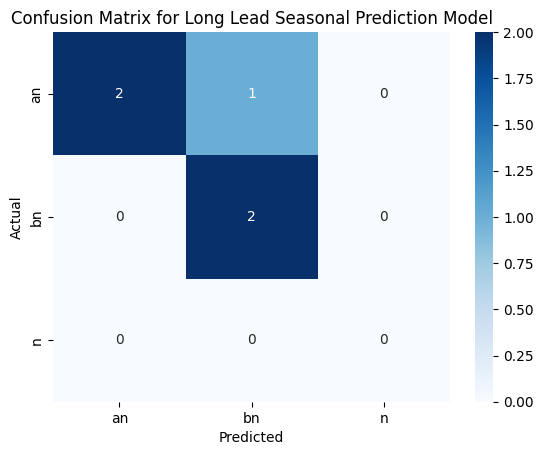

In [61]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Long Lead Seasonal Prediction Model')
plt.show()

<Figure size 1000x600 with 0 Axes>

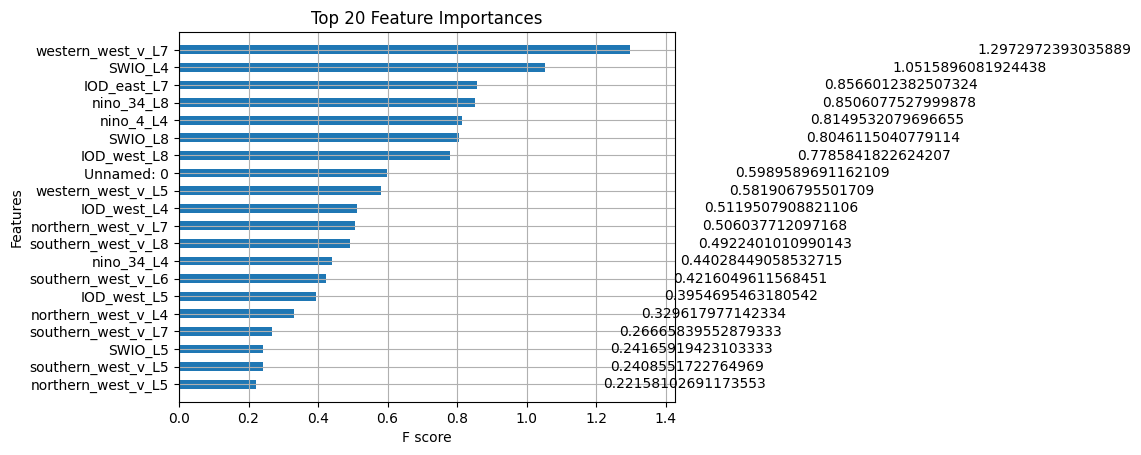

In [62]:
# Feature importance plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type='gain', height=0.5)
plt.title("Top 20 Feature Importances")
plt.show()

In [63]:
# Reset index to ensure alignment
test_info = test_df[['year']].reset_index(drop=True) # Only 'year' for seasonal data
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

# Concatenate year and predicted probabilities
results_df = pd.concat([test_info, proba_df], axis=1)

# Optional: add predicted and true class labels
results_df['true_label'] = le.inverse_transform(y_test_enc)
results_df['predicted_label'] = le.inverse_transform(y_pred)

# Print full DataFrame
print("=== EEA MAM Seasonal Predictions with Probabilities ===")
print(results_df.to_string(index=False))

=== EEA MAM Seasonal Predictions with Probabilities ===
 year  proba_an  proba_bn  proba_n true_label predicted_label
 2020  0.729452  0.202403 0.068145         an              an
 2021  0.241797  0.680769 0.077433         bn              bn
 2022  0.166830  0.740558 0.092613         bn              bn
 2023  0.233042  0.696634 0.070323         an              bn
 2024  0.697218  0.181953 0.120830         an              an


# Monthly Data with Monthly Terciles

For example, month 3 will have month 3's tercile, and so on and so forth.

In [64]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data/eea_mam_ml_data_monthly.csv", index_col=0)

# drop precip
df = df.drop(columns=['precip'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019, 2020]

test_years = [2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [65]:
# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [66]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       0.22      0.67      0.33         3
          bn       0.50      0.25      0.33         4
           n       0.00      0.00      0.00         5

    accuracy                           0.25        12
   macro avg       0.24      0.31      0.22        12
weighted avg       0.22      0.25      0.19        12



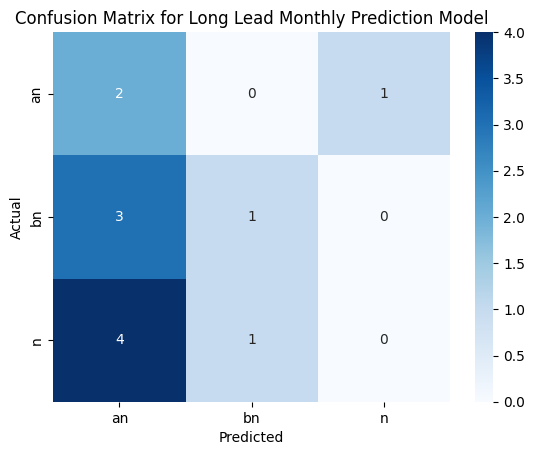

In [67]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Long Lead Monthly Prediction Model')
plt.show()

<Figure size 1000x600 with 0 Axes>

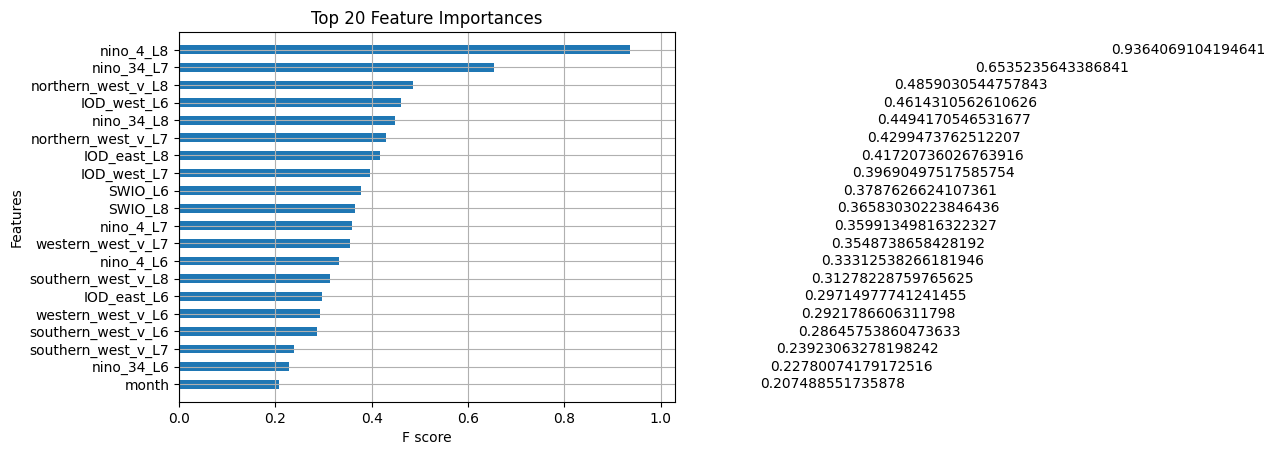

In [68]:
# Feature importance plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type='gain', height=0.5)
plt.title("Top 20 Feature Importances")
plt.show()

In [69]:
# Reset index to ensure alignment
test_info = test_df[['year']].reset_index(drop=True) # Only 'year' for seasonal data
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

# Concatenate year and predicted probabilities
results_df = pd.concat([test_info, proba_df], axis=1)

# Optional: add predicted and true class labels
results_df['true_label'] = le.inverse_transform(y_test_enc)
results_df['predicted_label'] = le.inverse_transform(y_pred)

# Print full DataFrame
print("=== EEA MAM Monthly Predictions with Probabilities ===")
print(results_df.to_string(index=False))

=== EEA MAM Seasonal Predictions with Probabilities ===
 year  proba_an  proba_bn  proba_n true_label predicted_label
 2021  0.686173  0.244765 0.069062         bn              an
 2022  0.297788  0.489544 0.212668          n              bn
 2023  0.288617  0.120757 0.590627         an               n
 2024  0.797414  0.113276 0.089310          n              an
 2021  0.746449  0.194068 0.059484          n              an
 2022  0.273479  0.376287 0.350234         bn              bn
 2023  0.672252  0.116978 0.210770         an              an
 2024  0.563079  0.220625 0.216296         an              an
 2021  0.511467  0.427405 0.061128          n              an
 2022  0.582584  0.208146 0.209270         bn              an
 2023  0.668455  0.144570 0.186975         bn              an
 2024  0.793233  0.126010 0.080757          n              an
